In [ ]:
!pip install -q AIUT_Environments

In [ ]:
# ============================================================
# Cell 1: Imports and GPU setup
# ============================================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import csv
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from AIUT_Environments.AIUT_Environments import MountainCar


# ------------------------------------------------------------
# GPU check
# ------------------------------------------------------------

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs found:", gpus)

if len(gpus) > 0:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print("GPU memory growth enabled.")
        print("Running on GPU:", gpus[0])

    except RuntimeError as e:
        print("GPU setup error:", e)
else:
    print("No GPU found by TensorFlow. The code will run on CPU.")

print("Logical devices:", tf.config.list_logical_devices())


TensorFlow version: 2.20.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.
Running on GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Logical devices: [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# Cell 2: Settings
# ============================================================

SEED = 7

MIN_TRAIN_EPISODES = 300

MAX_TRAIN_EPISODES = 600

max_steps = 200
GOAL_POSITION = 0.5

USE_REWARD_SHAPING = True


HEURISTIC_EPISODES = 40


EVAL_EVERY = 20
CHECKPOINT_EVAL_EPISODES = 20

STABLE_CHECKPOINTS = 3
TARGET_SUCCESS_RATE = 0.80
TARGET_MEAN_REWARD = -180.0
FINAL_EVAL_EPISODES = 50
FINAL_STABILITY_BLOCKS = 5
FINAL_MIN_BLOCK_SUCCESS = 0.60

BEST_WEIGHTS_PATH = "ddqn_aiut_best_guided_tf.weights.h5"
LAST_WEIGHTS_PATH = "ddqn_aiut_last_guided_tf.weights.h5"

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

ACTION_VALUES = np.array([-1, 0, 1], dtype=int)

print("Minimum training episodes:", MIN_TRAIN_EPISODES)
print("Maximum training episodes:", MAX_TRAIN_EPISODES)
print("Max steps per episode:", max_steps)
print("Heuristic episodes:", HEURISTIC_EPISODES)
print("Checkpoint evaluation:", CHECKPOINT_EVAL_EPISODES, "episodes every", EVAL_EVERY)
print("Final evaluation episodes:", FINAL_EVAL_EPISODES)
print("AIUT action values:", ACTION_VALUES)


Minimum training episodes: 300
Maximum training episodes: 600
Max steps per episode: 200
Heuristic episodes: 40
Checkpoint evaluation: 20 episodes every 20
Final evaluation episodes: 50
AIUT action values: [-1  0  1]


In [ ]:
# ============================================================
# Cell 3: Environment helper functions
# ============================================================

def reset_env(env, seed=None):
    
    if seed is None:
        result = env.reset()
    else:
        try:
            result = env.reset(seed=int(seed))
        except TypeError:
    
            if hasattr(env, "seed"):
                try:
                    env.seed(int(seed))
                except Exception:
                    pass
            result = env.reset()

    if isinstance(result, tuple):
        state = result[0]
    else:
        state = result

    return np.array(state, dtype=np.float32)


def step_env(env, action)
    result = env.step(int(action))

    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
        done = terminated or truncated

    elif len(result) == 4:
        next_state, reward, done, info = result

    elif len(result) == 3:
        next_state, reward, done = result

    else:
        raise RuntimeError("Unknown step output format from AIUT_Environments.")

    next_state = np.array(next_state, dtype=np.float32)
    reward = float(reward)
    done = bool(done)

    return next_state, reward, done


In [ ]:
# ============================================================
# Cell 4: Reward shaping and heuristic action
# ============================================================

def shape_reward(state, next_state, reward, done):
   
    if not USE_REWARD_SHAPING:
        return reward

    position = float(next_state[0])
    velocity = float(next_state[1])

    shaped = reward
    shaped += 15.0 * (position + 0.5)

    shaped += 70.0 * abs(velocity)

    if position > -0.2:
        shaped += 50.0 * (position + 0.2)

    if done and position >= GOAL_POSITION:
        shaped += 500.0

    return float(shaped)


def heuristic_action(state):
    velocity = float(state[1])
    return 0 if velocity < 0 else 2


In [6]:
# ============================================================
# Cell 5: Q-Network model
# ============================================================

class DQNmodel(tf.keras.Model):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)

        self.d1 = tf.keras.layers.Dense(64, activation="relu")
        self.d2 = tf.keras.layers.Dense(16, activation="relu")
        self.out = tf.keras.layers.Dense(self.action_dim, activation="linear")

    def call(self, input_data, training=False):
        x = tf.convert_to_tensor(input_data, dtype=tf.float32)
        x = self.d1(x)
        x = self.d2(x)
        return self.out(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "state_dim": self.state_dim,
            "action_dim": self.action_dim,
        })
        return config


In [ ]:
# ============================================================
# Cell 6: DDQN Agent - TensorFlow GPU friendly
# ============================================================

class DDQNTargetReplayAgent:
    def __init__(self, model, targetModel):
        self.model = model
        self.targetModel = targetModel
        self.targetUpdate()

        self.epsilon = 1.0
        self.EPSILON_END = 0.03
        self.EPSILON_DECAY = 0.985

        self.gamma = 0.99

        self.memory = deque(maxlen=20000)
        self.batch_size = 64
        self.train_start = 200

        self.state_dim = model.state_dim
        self.action_dim = model.action_dim

        self.optimizer = tf.keras.optimizers.Adam(
            learning_rate=5e-4,
            clipnorm=1.0
        )

        self.loss_fn = tf.keras.losses.Huber()

    def act(self, state, action_dim):
        if np.random.rand() < self.epsilon:
            return np.random.randint(action_dim)

        q_values = self.model(
            np.array([state], dtype=np.float32),
            training=False
        ).numpy()[0]

        return int(np.argmax(q_values))

    def greedy_act(self, state):
        q_values = self.model(
            np.array([state], dtype=np.float32),
            training=False
        ).numpy()[0]

        return int(np.argmax(q_values))

    def remember(self, state, action, reward, new_state, done):
        self.memory.append([
            np.array(state, dtype=np.float32),
            int(action),
            float(reward),
            np.array(new_state, dtype=np.float32),
            float(done)
        ])

    @tf.function
    def train_step(self, states, actions, rewards, next_states, dones):
        q_next_online = self.model(next_states, training=False)
        best_next_actions = tf.argmax(
            q_next_online,
            axis=1,
            output_type=tf.int32
        )

        q_next_target = self.targetModel(next_states, training=False)

        batch_indices = tf.range(tf.shape(states)[0], dtype=tf.int32)
        gather_indices = tf.stack([batch_indices, best_next_actions], axis=1)
        selected_q_next = tf.gather_nd(q_next_target, gather_indices)

        target_q = rewards + (1.0 - dones) * self.gamma * selected_q_next
        target_q = tf.stop_gradient(target_q)

        with tf.GradientTape() as tape:
            q_values = self.model(states, training=True)
            action_masks = tf.one_hot(actions, self.action_dim)
            selected_q_values = tf.reduce_sum(q_values * action_masks, axis=1)
            loss = self.loss_fn(target_q, selected_q_values)

        gradients = tape.gradient(loss, self.model.trainable_variables)

        gradient_variable_pairs = [
            (g, v)
            for g, v in zip(gradients, self.model.trainable_variables)
            if g is not None
        ]
        self.optimizer.apply_gradients(gradient_variable_pairs)

        return loss

    def train(self):
        if len(self.memory) < max(self.train_start, self.batch_size):
            return None

        mini_batch = random.sample(self.memory, self.batch_size)

        states = np.array([sample[0] for sample in mini_batch], dtype=np.float32)
        actions = np.array([sample[1] for sample in mini_batch], dtype=np.int32)
        rewards = np.array([sample[2] for sample in mini_batch], dtype=np.float32)
        next_states = np.array([sample[3] for sample in mini_batch], dtype=np.float32)
        dones = np.array([sample[4] for sample in mini_batch], dtype=np.float32)

        loss = self.train_step(
            tf.convert_to_tensor(states, dtype=tf.float32),
            tf.convert_to_tensor(actions, dtype=tf.int32),
            tf.convert_to_tensor(rewards, dtype=tf.float32),
            tf.convert_to_tensor(next_states, dtype=tf.float32),
            tf.convert_to_tensor(dones, dtype=tf.float32),
        )

        return float(loss.numpy())

    def decay_epsilon(self):
        if self.epsilon > self.EPSILON_END:
            self.epsilon *= self.EPSILON_DECAY
            self.epsilon = max(self.epsilon, self.EPSILON_END)

    def targetUpdate(self):
        self.targetModel.set_weights(self.model.get_weights())

    def load(self, file_name):
        self.model.load_weights(file_name)
        self.targetModel.load_weights(file_name)
        print(f"Loaded weights from {file_name}")

    def save(self, file_name):
        self.model.save_weights(file_name)
        print(f"Saved weights to {file_name}")


In [ ]:
# ============================================================
# Cell 7: Greedy evaluation functions
# ============================================================

def evaluate_aiut_model(model, episodes, seed_start=10000):
  
    eval_env = MountainCar()

    rewards = []
    steps_list = []
    max_positions = []
    successes = []

    for episode_index in range(int(episodes)):
        state = reset_env(eval_env, seed=seed_start + episode_index)

        done = False
        step_count = 0
        total_reward = 0.0
        max_position = float(state[0])

        while not done and step_count < max_steps:
            q_values = model(
                np.array([state], dtype=np.float32),
                training=False
            ).numpy()[0]

            action_index = int(np.argmax(q_values))
            env_action = int(ACTION_VALUES[action_index])

            next_state, reward, env_done = step_env(eval_env, env_action)

            step_count += 1
            done = bool(env_done or step_count >= max_steps)

            total_reward += float(reward)
            max_position = max(max_position, float(next_state[0]))
            state = next_state

        success = max_position >= GOAL_POSITION

        rewards.append(total_reward)
        steps_list.append(step_count)
        max_positions.append(max_position)
        successes.append(int(success))

    if hasattr(eval_env, "close"):
        eval_env.close()

    rewards = np.asarray(rewards, dtype=np.float64)
    steps_array = np.asarray(steps_list, dtype=np.int32)
    max_positions = np.asarray(max_positions, dtype=np.float64)
    successes = np.asarray(successes, dtype=np.int32)

    return {
        "rewards": rewards,
        "steps": steps_array,
        "max_positions": max_positions,
        "successes": successes,
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards, ddof=1)) if len(rewards) > 1 else 0.0,
        "median_reward": float(np.median(rewards)),
        "success_rate": float(np.mean(successes)),
        "mean_steps": float(np.mean(steps_array)),
        "std_steps": float(np.std(steps_array, ddof=1)) if len(steps_array) > 1 else 0.0,
    }


def stable_checkpoint_reached(mean_rewards, success_rates):

    if len(mean_rewards) < STABLE_CHECKPOINTS:
        return False

    recent_rewards = mean_rewards[-STABLE_CHECKPOINTS:]
    recent_success = success_rates[-STABLE_CHECKPOINTS:]

    reward_condition = all(
        value >= TARGET_MEAN_REWARD for value in recent_rewards
    )
    success_condition = all(
        value >= TARGET_SUCCESS_RATE for value in recent_success
    )

    return bool(reward_condition and success_condition)


In [ ]:
# ============================================================
# Cell 8: Create environment, models, and histories
# ============================================================

env = MountainCar()

state = reset_env(env, seed=SEED)
state_dim = len(state)
action_dim = len(ACTION_VALUES)

print("State dimension:", state_dim)
print("Action dimension:", action_dim)
print("AIUT action values:", ACTION_VALUES)

device_name = "/GPU:0" if len(tf.config.list_physical_devices("GPU")) > 0 else "/CPU:0"
print("Building models on:", device_name)

with tf.device(device_name):
    model = DQNmodel(state_dim, action_dim)
    targetModel = DQNmodel(state_dim, action_dim)

    dummy_input = np.zeros((1, state_dim), dtype=np.float32)
    model(dummy_input)
    targetModel(dummy_input)

    agent = DDQNTargetReplayAgent(model, targetModel)
    agent.targetUpdate()

original_reward_history = []
training_reward_history = []
max_position_history = []
episode_loss_history = []

evaluation_episode_history = []
evaluation_mean_reward_history = []
evaluation_std_reward_history = []
evaluation_success_rate_history = []
evaluation_mean_steps_history = []

best_eval_score = (-np.inf, -np.inf)
best_eval_episode = None
stable_convergence_episode = None

print("Ready for training and independent evaluation.")


State dimension: 2
Action dimension: 3
AIUT action values: [-1  0  1]
Building models on: /GPU:0
Ready for training and independent evaluation.


In [ ]:
# ============================================================
# Cell 9: Training loop with checkpoint evaluation
# ============================================================

for trial in range(MAX_TRAIN_EPISODES):
    episode_number = trial + 1

    done = False
    state = reset_env(env)

    total_original_reward = 0.0
    total_training_reward = 0.0

    step_count = 0
    episode_losses = []
    max_position = float(state[0])

    while not done and step_count < max_steps:

        if trial < HEURISTIC_EPISODES:
            action_index = heuristic_action(state)
        else:
            action_index = agent.act(state, action_dim)

        env_action = int(ACTION_VALUES[action_index])
        next_state, reward, env_done = step_env(env, env_action)

        step_count += 1
        done = bool(env_done or step_count >= max_steps)

        max_position = max(max_position, float(next_state[0]))

        train_reward = shape_reward(
            state=state,
            next_state=next_state,
            reward=reward,
            done=done
        )

        agent.remember(
            state,
            action_index,
            train_reward,
            next_state,
            done
        )

        loss = agent.train()
        if loss is not None:
            episode_losses.append(loss)

        state = next_state
        total_original_reward += float(reward)
        total_training_reward += float(train_reward)

    agent.targetUpdate()
    agent.decay_epsilon()

    original_reward_history.append(total_original_reward)
    training_reward_history.append(total_training_reward)
    max_position_history.append(max_position)

    mean_episode_loss = (
        float(np.mean(episode_losses))
        if len(episode_losses) > 0
        else np.nan
    )
    episode_loss_history.append(mean_episode_loss)

    if episode_number == 1 or episode_number % 10 == 0:
        recent_window = min(20, len(original_reward_history))
        train_avg = float(np.mean(original_reward_history[-recent_window:]))
        train_success = float(
            np.mean(
                np.asarray(max_position_history[-recent_window:])
                >= GOAL_POSITION
            )
        )

        print(
            "TRAIN | episode {:3d} | reward = {:7.1f} | "
            "avg{:02d} = {:7.2f} | success{:02d} = {:6.1%} | "
            "max_pos = {:6.3f} | epsilon = {:.4f} | mean_loss = {}".format(
                episode_number,
                total_original_reward,
                recent_window,
                train_avg,
                recent_window,
                train_success,
                max_position,
                agent.epsilon,
                "nan" if np.isnan(mean_episode_loss)
                else f"{mean_episode_loss:.5f}"
            )
        )

    if episode_number % EVAL_EVERY == 0:
        checkpoint_eval = evaluate_aiut_model(
            model=agent.model,
            episodes=CHECKPOINT_EVAL_EPISODES,
            seed_start=20000 + episode_number * 100
        )

        evaluation_episode_history.append(episode_number)
        evaluation_mean_reward_history.append(
            checkpoint_eval["mean_reward"]
        )
        evaluation_std_reward_history.append(
            checkpoint_eval["std_reward"]
        )
        evaluation_success_rate_history.append(
            checkpoint_eval["success_rate"]
        )
        evaluation_mean_steps_history.append(
            checkpoint_eval["mean_steps"]
        )

        print(
            "EVAL  | episode {:3d} | mean_reward = {:7.2f} ± {:6.2f} | "
            "success = {:6.1%} | mean_steps = {:6.2f}".format(
                episode_number,
                checkpoint_eval["mean_reward"],
                checkpoint_eval["std_reward"],
                checkpoint_eval["success_rate"],
                checkpoint_eval["mean_steps"]
            )
        )

        current_score = (
            checkpoint_eval["success_rate"],
            checkpoint_eval["mean_reward"]
        )

        if current_score > best_eval_score:
            best_eval_score = current_score
            best_eval_episode = episode_number
            agent.save(BEST_WEIGHTS_PATH)
            print(
                "NEW BEST CHECKPOINT | episode =", best_eval_episode,
                "| score =", best_eval_score
            )

        if (
            episode_number >= MIN_TRAIN_EPISODES
            and stable_checkpoint_reached(
                evaluation_mean_reward_history,
                evaluation_success_rate_history
            )
        ):
            stable_convergence_episode = episode_number
            print(
                "\nStable convergence detected at episode",
                stable_convergence_episode,
                "after",
                STABLE_CHECKPOINTS,
                "consecutive greedy evaluations."
            )
            break

agent.save(LAST_WEIGHTS_PATH)

if hasattr(env, "close"):
    env.close()

completed_episodes = len(original_reward_history)

if not os.path.exists(BEST_WEIGHTS_PATH):
    agent.save(BEST_WEIGHTS_PATH)
    best_eval_episode = completed_episodes

print("\nTraining completed.")
print("Completed episodes:", completed_episodes)
print("Best checkpoint episode:", best_eval_episode)
print("Stable convergence episode:", stable_convergence_episode)


TRAIN | episode   1 | reward =  -117.0 | avg01 = -117.00 | success01 = 100.0% | max_pos =  0.500 | epsilon = 0.9850 | mean_loss = nan
TRAIN | episode  10 | reward =  -112.0 | avg10 = -118.40 | success10 = 100.0% | max_pos =  0.500 | epsilon = 0.8597 | mean_loss = 7.52090
TRAIN | episode  20 | reward =  -120.0 | avg20 = -118.70 | success20 = 100.0% | max_pos =  0.500 | epsilon = 0.7391 | mean_loss = 7.25084
EVAL  | episode  20 | mean_reward = -200.00 ±   0.00 | success =   0.0% | mean_steps = 200.00
Saved weights to ddqn_aiut_best_guided_tf.weights.h5
NEW BEST CHECKPOINT | episode = 20 | score = (0.0, -200.0)
TRAIN | episode  30 | reward =  -115.0 | avg20 = -118.35 | success20 = 100.0% | max_pos =  0.500 | epsilon = 0.6355 | mean_loss = 17.69363
TRAIN | episode  40 | reward =  -116.0 | avg20 = -117.60 | success20 = 100.0% | max_pos =  0.500 | epsilon = 0.5463 | mean_loss = 35.77736
EVAL  | episode  40 | mean_reward = -200.00 ±   0.00 | success =   0.0% | mean_steps = 200.00
TRAIN | epis

In [ ]:
# ============================================================
# Cell 10: Load best checkpoint and run final AIUT evaluation
# ============================================================

agent.load(BEST_WEIGHTS_PATH)

final_eval = evaluate_aiut_model(
    model=agent.model,
    episodes=FINAL_EVAL_EPISODES,
    seed_start=50000
)

n_eval = FINAL_EVAL_EPISODES

reward_sem = (
    final_eval["std_reward"] / np.sqrt(n_eval)
    if n_eval > 1
    else 0.0
)
reward_ci_low = final_eval["mean_reward"] - 1.96 * reward_sem
reward_ci_high = final_eval["mean_reward"] + 1.96 * reward_sem

p_success = final_eval["success_rate"]
success_sem = np.sqrt(
    max(p_success * (1.0 - p_success), 0.0) / n_eval
)
success_ci_low = max(0.0, p_success - 1.96 * success_sem)
success_ci_high = min(1.0, p_success + 1.96 * success_sem)

print("=" * 78)
print("FINAL GREEDY EVALUATION ON AIUT MOUNTAINCAR")
print("=" * 78)
print("Weights:", BEST_WEIGHTS_PATH)
print("Evaluation episodes:", n_eval)
print("Mean original reward: {:.3f}".format(final_eval["mean_reward"]))
print("Reward standard deviation: {:.3f}".format(final_eval["std_reward"]))
print(
    "95% CI for mean reward: [{:.3f}, {:.3f}]".format(
        reward_ci_low,
        reward_ci_high
    )
)
print("Median original reward: {:.3f}".format(final_eval["median_reward"]))
print("Success rate: {:.2%}".format(final_eval["success_rate"]))
print(
    "95% CI for success rate: [{:.2%}, {:.2%}]".format(
        success_ci_low,
        success_ci_high
    )
)
print("Mean steps: {:.3f}".format(final_eval["mean_steps"]))
print("Steps standard deviation: {:.3f}".format(final_eval["std_steps"]))
print(
    "Mean maximum position: {:.4f}".format(
        float(np.mean(final_eval["max_positions"]))
    )
)


Loaded weights from ddqn_aiut_best_guided_tf.weights.h5
FINAL GREEDY EVALUATION ON AIUT MOUNTAINCAR
Weights: ddqn_aiut_best_guided_tf.weights.h5
Evaluation episodes: 50
Mean original reward: -145.220
Reward standard deviation: 21.932
95% CI for mean reward: [-151.299, -139.141]
Median original reward: -151.000
Success rate: 98.00%
95% CI for success rate: [94.12%, 100.00%]
Mean steps: 146.200
Steps standard deviation: 21.882
Mean maximum position: 0.4971


In [12]:
# ============================================================
# Cell 11: Stability analysis across independent blocks
# ============================================================

if FINAL_EVAL_EPISODES % FINAL_STABILITY_BLOCKS != 0:
    raise ValueError(
        "FINAL_EVAL_EPISODES must be divisible by FINAL_STABILITY_BLOCKS."
    )

block_size = FINAL_EVAL_EPISODES // FINAL_STABILITY_BLOCKS

block_mean_rewards = []
block_success_rates = []
block_mean_steps = []

print("\n" + "=" * 78)
print("FINAL EVALUATION STABILITY BY BLOCK")
print("=" * 78)
print(
    "{:<8s} {:>15s} {:>15s} {:>15s}".format(
        "Block",
        "Mean reward",
        "Success rate",
        "Mean steps"
    )
)

for block_index in range(FINAL_STABILITY_BLOCKS):
    start = block_index * block_size
    end = start + block_size

    block_rewards = final_eval["rewards"][start:end]
    block_successes = final_eval["successes"][start:end]
    block_steps = final_eval["steps"][start:end]

    mean_reward = float(np.mean(block_rewards))
    success_rate = float(np.mean(block_successes))
    mean_steps = float(np.mean(block_steps))

    block_mean_rewards.append(mean_reward)
    block_success_rates.append(success_rate)
    block_mean_steps.append(mean_steps)

    print(
        "{:<8d} {:>15.3f} {:>14.2%} {:>15.3f}".format(
            block_index + 1,
            mean_reward,
            success_rate,
            mean_steps
        )
    )

checkpoint_stability = stable_checkpoint_reached(
    evaluation_mean_reward_history,
    evaluation_success_rate_history
)

final_stability = bool(
    final_eval["success_rate"] >= TARGET_SUCCESS_RATE
    and final_eval["mean_reward"] >= TARGET_MEAN_REWARD
    and min(block_success_rates) >= FINAL_MIN_BLOCK_SUCCESS
)

print("\nCheckpoint stability:", checkpoint_stability)
print("Final multi-block stability:", final_stability)

if checkpoint_stability and final_stability:
    convergence_status = "STABLE CONVERGENCE CONFIRMED"
elif final_stability:
    convergence_status = (
        "FINAL POLICY IS STABLE, BUT CHECKPOINT HISTORY DID NOT MEET "
        "ALL CONSECUTIVE CRITERIA"
    )
else:
    convergence_status = (
        "STABLE CONVERGENCE NOT CONFIRMED; MORE TRAINING OR TUNING IS NEEDED"
    )

print("Convergence conclusion:", convergence_status)



FINAL EVALUATION STABILITY BY BLOCK
Block        Mean reward    Success rate      Mean steps
1               -147.900        100.00%         148.900
2               -153.900         90.00%         154.800
3               -131.900        100.00%         132.900
4               -146.500        100.00%         147.500
5               -145.900        100.00%         146.900

Checkpoint stability: True
Final multi-block stability: True
Convergence conclusion: STABLE CONVERGENCE CONFIRMED


In [13]:
# ============================================================
# Cell 12: Save evaluation results to CSV
# ============================================================

checkpoint_csv = "ddqn_aiut_checkpoint_evaluation.csv"

with open(checkpoint_csv, "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow([
        "training_episode",
        "mean_reward",
        "std_reward",
        "success_rate",
        "mean_steps"
    ])

    for row in zip(
        evaluation_episode_history,
        evaluation_mean_reward_history,
        evaluation_std_reward_history,
        evaluation_success_rate_history,
        evaluation_mean_steps_history
    ):
        writer.writerow(row)

final_csv = "ddqn_aiut_final_evaluation_50_episodes.csv"

with open(final_csv, "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow([
        "evaluation_episode",
        "reward",
        "steps",
        "max_position",
        "success"
    ])

    for index in range(FINAL_EVAL_EPISODES):
        writer.writerow([
            index + 1,
            final_eval["rewards"][index],
            final_eval["steps"][index],
            final_eval["max_positions"][index],
            final_eval["successes"][index]
        ])

print("Saved:", checkpoint_csv)
print("Saved:", final_csv)


Saved: ddqn_aiut_checkpoint_evaluation.csv
Saved: ddqn_aiut_final_evaluation_50_episodes.csv


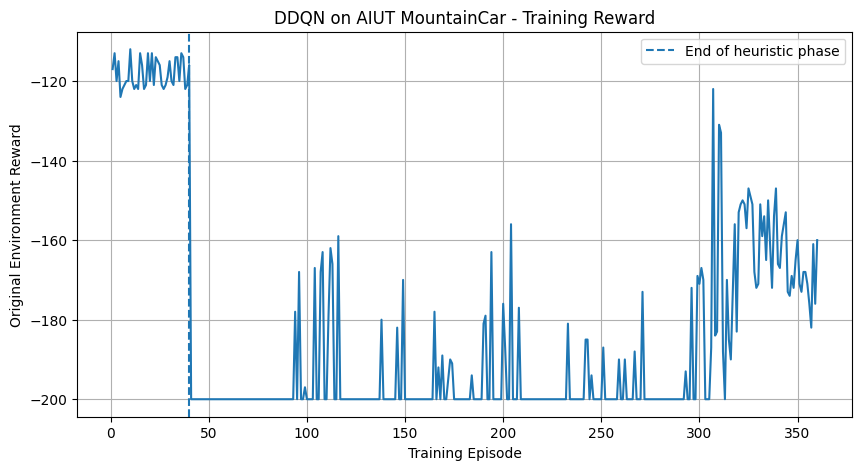

In [14]:
# ============================================================
# Cell 13: Plot original training rewards
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, completed_episodes + 1),
    original_reward_history
)
plt.axvline(
    HEURISTIC_EPISODES,
    linestyle="--",
    label="End of heuristic phase"
)
plt.xlabel("Training Episode")
plt.ylabel("Original Environment Reward")
plt.title("DDQN on AIUT MountainCar - Training Reward")
plt.grid(True)
plt.legend()
plt.savefig(
    "ddqn_aiut_training_original_rewards.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


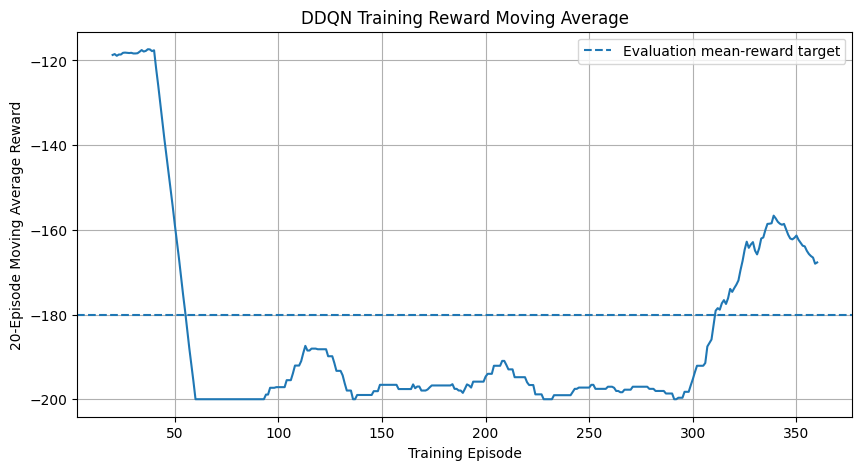

In [15]:
# ============================================================
# Cell 14: Plot moving average training reward
# ============================================================

window = 20

if len(original_reward_history) >= window:
    moving_avg = np.convolve(
        original_reward_history,
        np.ones(window) / window,
        mode="valid"
    )

    moving_x = np.arange(window, completed_episodes + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(moving_x, moving_avg)
    plt.axhline(
        TARGET_MEAN_REWARD,
        linestyle="--",
        label="Evaluation mean-reward target"
    )
    plt.xlabel("Training Episode")
    plt.ylabel(f"{window}-Episode Moving Average Reward")
    plt.title("DDQN Training Reward Moving Average")
    plt.grid(True)
    plt.legend()
    plt.savefig(
        "ddqn_aiut_training_moving_average.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()


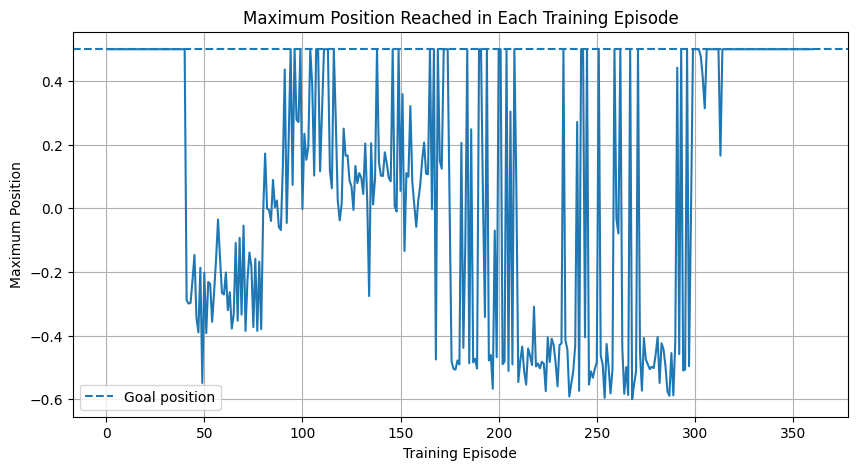

In [16]:
# ============================================================
# Cell 15: Plot maximum position reached during training
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, completed_episodes + 1),
    max_position_history
)
plt.axhline(
    y=GOAL_POSITION,
    linestyle="--",
    label="Goal position"
)
plt.xlabel("Training Episode")
plt.ylabel("Maximum Position")
plt.title("Maximum Position Reached in Each Training Episode")
plt.grid(True)
plt.legend()
plt.savefig(
    "ddqn_aiut_training_max_position.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


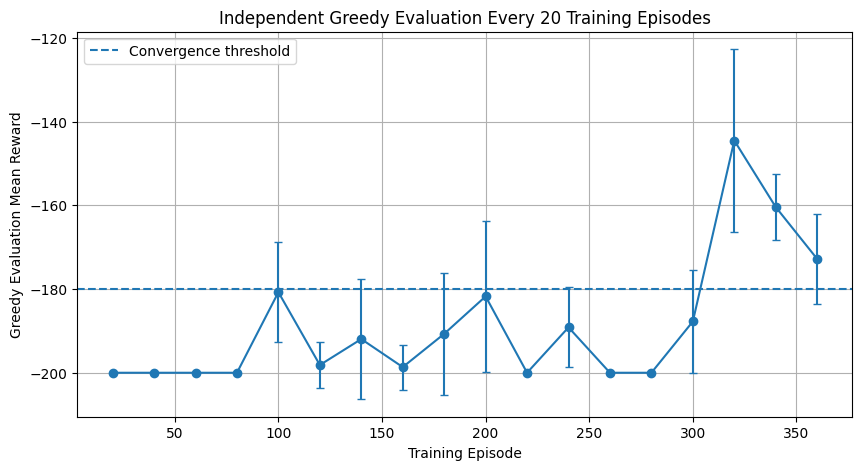

In [17]:
# ============================================================
# Cell 16: Plot independent checkpoint mean rewards
# ============================================================

plt.figure(figsize=(10, 5))
plt.errorbar(
    evaluation_episode_history,
    evaluation_mean_reward_history,
    yerr=evaluation_std_reward_history,
    marker="o",
    capsize=3
)
plt.axhline(
    TARGET_MEAN_REWARD,
    linestyle="--",
    label="Convergence threshold"
)
plt.xlabel("Training Episode")
plt.ylabel("Greedy Evaluation Mean Reward")
plt.title(
    f"Independent Greedy Evaluation Every {EVAL_EVERY} Training Episodes"
)
plt.grid(True)
plt.legend()
plt.savefig(
    "ddqn_aiut_checkpoint_mean_reward.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


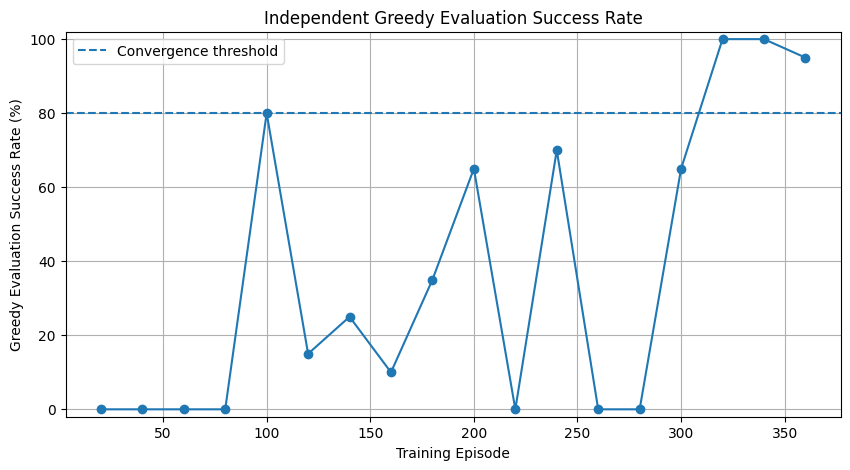

In [18]:
# ============================================================
# Cell 17: Plot independent checkpoint success rates
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    evaluation_episode_history,
    np.asarray(evaluation_success_rate_history) * 100.0,
    marker="o"
)
plt.axhline(
    TARGET_SUCCESS_RATE * 100.0,
    linestyle="--",
    label="Convergence threshold"
)
plt.ylim(-2, 102)
plt.xlabel("Training Episode")
plt.ylabel("Greedy Evaluation Success Rate (%)")
plt.title("Independent Greedy Evaluation Success Rate")
plt.grid(True)
plt.legend()
plt.savefig(
    "ddqn_aiut_checkpoint_success_rate.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


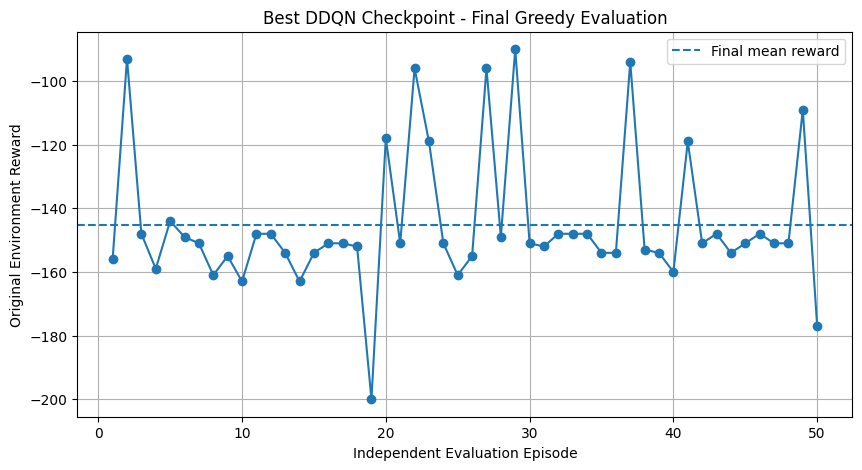

In [19]:
# ============================================================
# Cell 18: Plot final evaluation episode rewards
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, FINAL_EVAL_EPISODES + 1),
    final_eval["rewards"],
    marker="o"
)
plt.axhline(
    final_eval["mean_reward"],
    linestyle="--",
    label="Final mean reward"
)
plt.xlabel("Independent Evaluation Episode")
plt.ylabel("Original Environment Reward")
plt.title("Best DDQN Checkpoint - Final Greedy Evaluation")
plt.grid(True)
plt.legend()
plt.savefig(
    "ddqn_aiut_final_evaluation_rewards.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


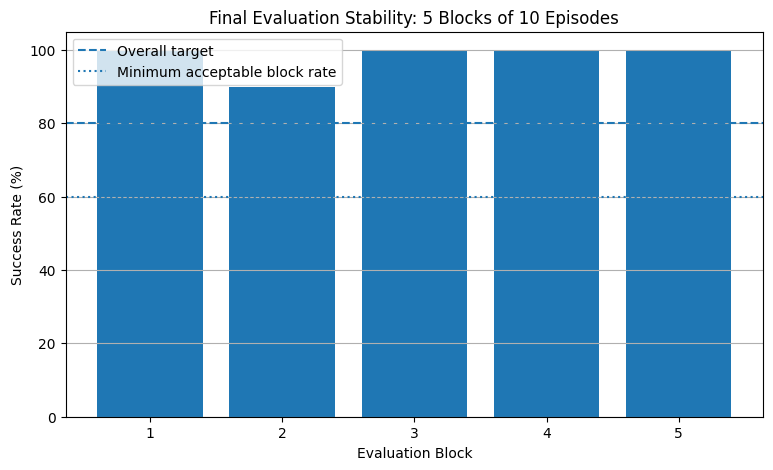

In [20]:
# ============================================================
# Cell 19: Plot block-level stability
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(
    np.arange(1, FINAL_STABILITY_BLOCKS + 1),
    np.asarray(block_success_rates) * 100.0
)
plt.axhline(
    TARGET_SUCCESS_RATE * 100.0,
    linestyle="--",
    label="Overall target"
)
plt.axhline(
    FINAL_MIN_BLOCK_SUCCESS * 100.0,
    linestyle=":",
    label="Minimum acceptable block rate"
)
plt.ylim(0, 105)
plt.xlabel("Evaluation Block")
plt.ylabel("Success Rate (%)")
plt.title(
    f"Final Evaluation Stability: {FINAL_STABILITY_BLOCKS} Blocks "
    f"of {block_size} Episodes"
)
plt.grid(True, axis="y")
plt.legend()
plt.savefig(
    "ddqn_aiut_final_block_stability.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


In [21]:
# ============================================================
# Cell 20: Final report
# ============================================================

print("=" * 78)
print("FINAL DDQN REPORT")
print("=" * 78)
print("Completed training episodes:", completed_episodes)
print("Heuristic episodes:", HEURISTIC_EPISODES)
print("Best checkpoint episode:", best_eval_episode)
print("Stable convergence episode:", stable_convergence_episode)
print("Best weights file:", BEST_WEIGHTS_PATH)
print("Last weights file:", LAST_WEIGHTS_PATH)
print("Final greedy mean reward:", final_eval["mean_reward"])
print("Final greedy reward std:", final_eval["std_reward"])
print("Final greedy success rate:", final_eval["success_rate"])
print("Final greedy mean steps:", final_eval["mean_steps"])
print("Minimum block success rate:", min(block_success_rates))
print("Convergence conclusion:", convergence_status)
print("GPUs:", tf.config.list_physical_devices("GPU"))


FINAL DDQN REPORT
Completed training episodes: 360
Heuristic episodes: 40
Best checkpoint episode: 320
Stable convergence episode: 360
Best weights file: ddqn_aiut_best_guided_tf.weights.h5
Last weights file: ddqn_aiut_last_guided_tf.weights.h5
Final greedy mean reward: -145.22
Final greedy reward std: 21.932447307538645
Final greedy success rate: 0.98
Final greedy mean steps: 146.2
Minimum block success rate: 0.9
Convergence conclusion: STABLE CONVERGENCE CONFIRMED
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## S2

In [ ]:
!pip install -q "gymnasium[classic-control]" moviepy imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 120.5 MB/s eta 0:00:00


In [23]:
# ============================================================
# Cell 22: Gymnasium imports and video helper
# ============================================================

import glob
import base64

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display


def show_video(video_path):
    with open(video_path, "rb") as video_file:
        mp4 = video_file.read()

    data_url = (
        "data:video/mp4;base64,"
        + base64.b64encode(mp4).decode()
    )

    return HTML(
        """
        <video width="640" height="480" controls>
            <source src="{}" type="video/mp4">
        </video>
        """.format(data_url)
    )


print("Gymnasium video tools are ready.")


Gymnasium video tools are ready.


In [ ]:
# ============================================================
# Cell 23: Multi-seed Gymnasium evaluation without retraining
# ============================================================

Q1_WEIGHTS_PATH = BEST_WEIGHTS_PATH
GYM_EVAL_EPISODES = 20

q2_model = DQNmodel(2, 3)
q2_model(np.zeros((1, 2), dtype=np.float32))

if os.path.exists(Q1_WEIGHTS_PATH):
    q2_model.load_weights(Q1_WEIGHTS_PATH)
    print("Loaded Question 1 best weights from:", Q1_WEIGHTS_PATH)
else:
    q2_model.set_weights(agent.model.get_weights())
    print("Best weights file not found; used current Question 1 model weights.")

gym_rewards = []
gym_steps = []
gym_max_positions = []
gym_successes = []
gym_seeds = []

eval_gym_env = gym.make("MountainCar-v0")

for episode_index in range(GYM_EVAL_EPISODES):
    episode_seed = SEED + episode_index
    state, info = eval_gym_env.reset(seed=episode_seed)
    state = np.asarray(state, dtype=np.float32)

    done = False
    step_count = 0
    total_reward = 0.0
    max_position = float(state[0])

    while not done and step_count < max_steps:
        q_values = q2_model(
            np.array([state], dtype=np.float32),
            training=False
        ).numpy()[0]

        action = int(np.argmax(q_values))

        next_state, reward, terminated, truncated, info = (
            eval_gym_env.step(action)
        )

        done = bool(terminated or truncated)
        step_count += 1

        next_state = np.asarray(next_state, dtype=np.float32)
        max_position = max(max_position, float(next_state[0]))

        state = next_state
        total_reward += float(reward)

    success = max_position >= GOAL_POSITION

    gym_seeds.append(episode_seed)
    gym_rewards.append(total_reward)
    gym_steps.append(step_count)
    gym_max_positions.append(max_position)
    gym_successes.append(int(success))

eval_gym_env.close()

gym_rewards = np.asarray(gym_rewards, dtype=np.float64)
gym_steps = np.asarray(gym_steps, dtype=np.int32)
gym_max_positions = np.asarray(gym_max_positions, dtype=np.float64)
gym_successes = np.asarray(gym_successes, dtype=np.int32)

print("=" * 78)
print("GYMNASIUM MULTI-SEED EVALUATION - NO RETRAINING")
print("=" * 78)
print("Episodes:", GYM_EVAL_EPISODES)
print("Mean reward:", float(np.mean(gym_rewards)))
print(
    "Reward standard deviation:",
    float(np.std(gym_rewards, ddof=1))
)
print("Success rate:", float(np.mean(gym_successes)))
print("Mean steps:", float(np.mean(gym_steps)))
print("Best reward:", float(np.max(gym_rewards)))
print("Worst reward:", float(np.min(gym_rewards)))


Loaded Question 1 best weights from: ddqn_aiut_best_guided_tf.weights.h5
GYMNASIUM MULTI-SEED EVALUATION - NO RETRAINING
Episodes: 20
Mean reward: -138.5
Reward standard deviation: 30.909886001594682
Success rate: 1.0
Mean steps: 138.5
Best reward: -92.0
Worst reward: -179.0


In [ ]:
# ============================================================
# Cell 24: Record one Gymnasium episode for graphical display
# ============================================================

successful_indices = np.where(gym_successes == 1)[0]

if len(successful_indices) > 0:
    video_seed = int(gym_seeds[int(successful_indices[0])])
else:
    video_seed = int(SEED)

video_folder = "q2_gymnasium_video"
os.makedirs(video_folder, exist_ok=True)

for old_video in glob.glob(os.path.join(video_folder, "*.mp4")):
    try:
        os.remove(old_video)
    except OSError:
        pass

video_env = gym.make("MountainCar-v0", render_mode="rgb_array")
video_env = RecordVideo(
    video_env,
    video_folder=video_folder,
    episode_trigger=lambda episode_id: True,
    name_prefix="q2_best_weights_test"
)

state, info = video_env.reset(seed=video_seed)
state = np.asarray(state, dtype=np.float32)

done = False
step_count = 0
total_reward = 0.0
max_position = float(state[0])

while not done and step_count < max_steps:
    q_values = q2_model(
        np.array([state], dtype=np.float32),
        training=False
    ).numpy()[0]

    action = int(np.argmax(q_values))

    next_state, reward, terminated, truncated, info = video_env.step(action)

    done = bool(terminated or truncated)
    step_count += 1

    next_state = np.asarray(next_state, dtype=np.float32)
    max_position = max(max_position, float(next_state[0]))

    state = next_state
    total_reward += float(reward)

video_env.close()

solved_q2 = max_position >= GOAL_POSITION

print("Video seed:", video_seed)
print("Gymnasium video reward:", total_reward)
print("Gymnasium video steps:", step_count)
print("Gymnasium video max_position:", max_position)
print("Solved with Question 1 weights:", solved_q2)

videos = sorted(glob.glob(os.path.join(video_folder, "*.mp4")))
print("Saved videos:", videos)

if len(videos) > 0:
    display(show_video(videos[-1]))


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/q2_gymnasium_video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Video seed: 7
Gymnasium video reward: -164.0
Gymnasium video steps: 164
Gymnasium video max_position: 0.5006933808326721
Solved with Question 1 weights: True
Saved videos: ['q2_gymnasium_video/q2_best_weights_test-episode-0.mp4']
